# 01 - EDA (Exploration des données)


In [17]:
import sys, os
sys.path.append(os.path.abspath('../src'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from extract import read_source_csv, rename_columns_for_staging

pd.set_option('display.max_columns', None)

## 1. Chargement du fichier source brut

In [18]:
df = read_source_csv('../data/raw/Sample - Superstore.csv')
df = rename_columns_for_staging(df)
print(df.shape)
df.head()

(10064, 21)


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2.0,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.0,0.0,219.582
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,0.0,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.031
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2.0,0.2,2.5164


## 2. Structure générale : types, valeurs non nulles

In [ ]:
df.info()

## 3. Valeurs manquantes par colonne

In [ ]:

df.isna().sum().sort_values(ascending=False)

## 4. Doublons

On regarde 2 choses : les doublons EXACTS (toutes colonnes identiques), et les doublons sur row_id (qui est censé être unique).

In [19]:
print('Doublons exacts (toutes colonnes) :', df.duplicated().sum())
print('Doublons sur row_id :', df.duplicated(subset=['row_id']).sum())

Doublons exacts (toutes colonnes) : 34
Doublons sur row_id : 70


## 5. Statistiques descriptives des colonnes numériques

In [9]:
df_num = df[['sales', 'quantity', 'discount', 'profit']].apply(pd.to_numeric, errors='coerce')
df_num.describe()

,sales,quantity,discount,profit
count,9.863000e+03,9865.000000,10064.000000,10064.000000
mean,1.950322e+03,3.780233,0.157501,28.571309
std,4.410673e+04,2.240134,0.210586,233.509461
min,4.440000e-01,-5.000000,0.000000,-6599.978000
25%,1.729000e+01,2.000000,0.000000,1.724800
50%,5.450000e+01,3.000000,0.200000,8.643600
75%,2.107600e+02,5.000000,0.200000,29.331600
max,1.131924e+06,14.000000,1.500000,8399.976000


## 6. Valeurs aberrantes potentielles (règles de gestion du brief)

In [10]:
print('Discount > 1 (>100%)   :', (df_num['discount'] > 1).sum())
print('Quantity < 0            :', (df_num['quantity'] < 0).sum())
print('Profit négatif (normal, à ne PAS traiter comme anomalie) :', (df_num['profit'] < 0).sum())

Discount > 1 (>100%)   : 10
Quantity < 0            : 10
Profit négatif (normal, à ne PAS traiter comme anomalie) : 1885


## 7. Tendances par catégorie / région / segment

In [20]:
df_tmp = df.copy()
df_tmp['sales'] = df_num['sales']
df_tmp['category'] = df_tmp['category'].str.strip().str.title()

ventes_categorie = df_tmp.groupby('category')['sales'].sum().sort_values(ascending=False)
ventes_categorie

category
Office Supplies    9.762896e+06
Furniture          6.391206e+06
Technology         3.081925e+06
Name: sales, dtype: float64

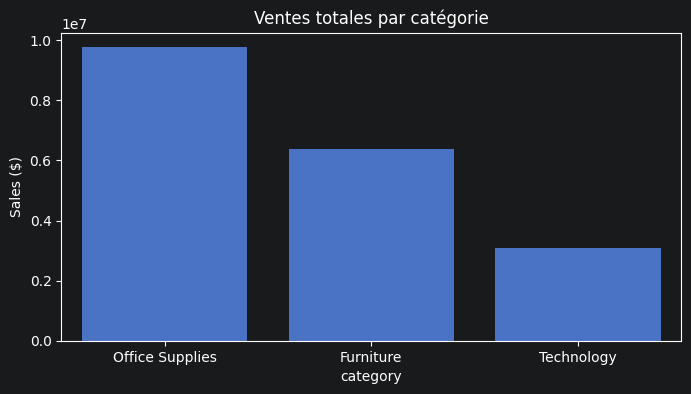

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=ventes_categorie.index, y=ventes_categorie.values, ax=ax)
ax.set_title('Ventes totales par catégorie')
ax.set_ylabel('Sales ($)')
plt.show()

In [22]:
ventes_region = df_tmp.groupby('region')['sales'].sum().sort_values(ascending=False)
ventes_region

region
West       7.503194e+06
Central    7.275085e+06
East       2.935334e+06
South      1.522413e+06
Name: sales, dtype: float64

In [23]:
# df_tmp['segment'] = df_tmp['segment'].str.strip().str.title()
ventes_segment = df_tmp.groupby('segment')['sales'].sum().sort_values(ascending=False)
ventes_segment

segment
Consumer       1.017622e+07
Corporate      5.216749e+06
Home Office    3.821814e+06
Consumerr      1.113247e+04
Corporrate     6.710572e+03
Home Ofice     3.401599e+03
Name: sales, dtype: float64

## 8. Corrélations entre variables numériques

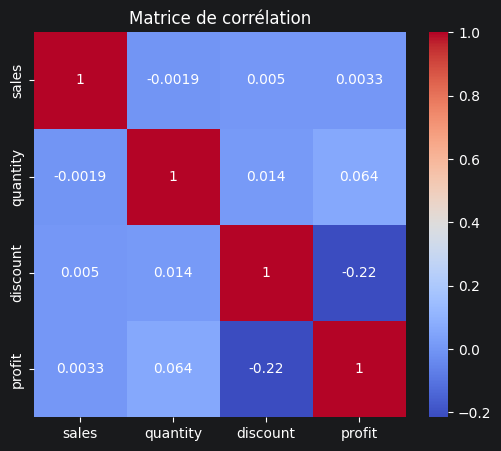

In [24]:
plt.figure(figsize=(6, 5))
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation')
plt.show()